In [1]:
import json
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set up paths (Colab environment)
BASE_DIR = Path("/content/drive/MyDrive/ML_Ass_2")
DATA_PATH = BASE_DIR / "default of credit card clients.xlsx"
EDA_DIR = BASE_DIR / "eda_outputs"
PROCESSED_DIR = BASE_DIR / "processed"
EDA_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

# Plotting config
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 6), "axes.titlesize": 14})

TARGET = "default payment next month"
ML_TARGET = "default"
PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYAMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
CONTINUOUS_COLS = ["LIMIT_BAL", "AGE", *BILL_COLS, *PAYAMT_COLS]
CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]

TEST_SIZE = 0.20
RANDOM_STATE = 42

SEX_MAP = {1: "Male", 2: "Female"}
EDU_MAP = {1: "Graduate school", 2: "University", 3: "High school", 4: "Others", 0: "Undocumented (0)", 5: "Undocumented (5)", 6: "Undocumented (6)"}
MAR_MAP = {1: "Married", 2: "Single", 3: "Others", 0: "Undocumented (0)"}
EDU_CLEAN_MAP = {k: EDU_MAP[k] for k in (1, 2, 3, 4)}
MAR_CLEAN_MAP = {k: MAR_MAP[k] for k in (1, 2, 3)}

In [2]:
def load_data() -> pd.DataFrame:
    df = pd.read_excel(DATA_PATH, header=1)
    df.columns = df.columns.str.strip()
    return df

def section(title: str) -> None:
    print(f"\n{'='*80}\n{title}\n{'='*80}")

def run_basic_eda(df: pd.DataFrame):
    section("Dataset Overview")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

    section("Data Quality")
    print(f"Missing cells: {int(df.isna().sum().sum())}")
    print(f"Duplicate IDs: {int(df['ID'].duplicated().sum())}")

    section("Descriptive Statistics")
    numeric = df[CONTINUOUS_COLS]
    stats = numeric.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
    print(stats.round(2).to_string())

df_raw = load_data()
run_basic_eda(df_raw)


Dataset Overview
Shape: 30,000 rows x 25 columns

Data Quality
Missing cells: 0
Duplicate IDs: 0

Descriptive Statistics
             count       mean        std       min        1%       5%       50%        95%        99%        max
LIMIT_BAL  30000.0  167484.32  129747.66   10000.0  10000.00  20000.0  140000.0  430000.00  500000.00  1000000.0
AGE        30000.0      35.49       9.22      21.0     22.00     23.0      34.0      53.00      60.00       79.0
BILL_AMT1  30000.0   51223.33   73635.86 -165580.0    -81.00      0.0   22381.5  201203.05  350110.68   964511.0
BILL_AMT2  30000.0   49179.08   71173.77  -69777.0   -200.00      0.0   21200.0  194792.20  337495.28   983931.0
BILL_AMT3  30000.0   47013.15   69349.39 -157264.0   -200.00      0.0   20088.5  187821.05  325030.39  1664089.0
BILL_AMT4  30000.0   43262.95   64332.86 -170000.0   -212.02      0.0   19052.0  174333.35  304997.27   891586.0
BILL_AMT5  30000.0   40311.40   60797.16  -81334.0   -232.01      0.0   18104.5  165794


Target Distribution


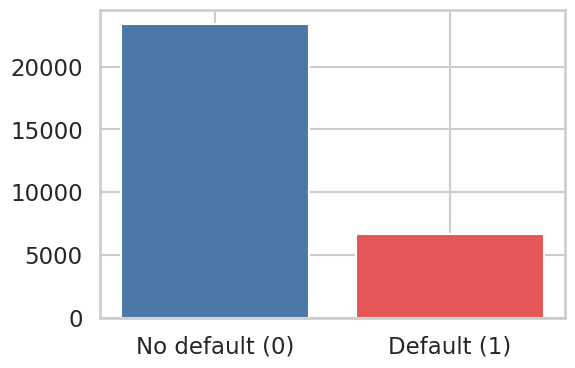


Age and Credit Limit Distributions


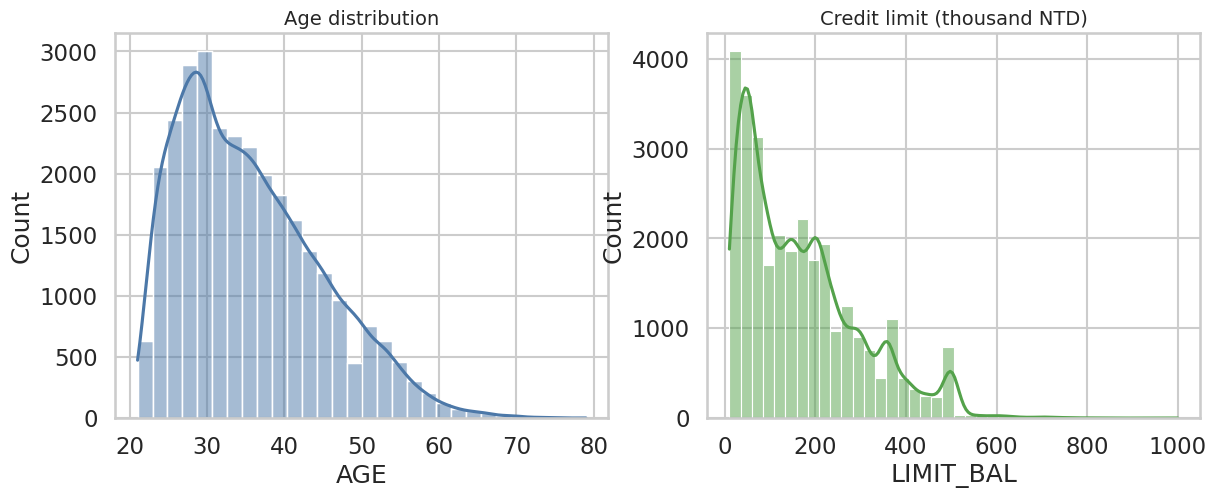

In [3]:
def show_visualizations(df: pd.DataFrame):
    section("Target Distribution")
    counts = df[TARGET].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["No default (0)", "Default (1)"], counts.values, color=["#4C78A8", "#E45756"])
    plt.show()

    section("Age and Credit Limit Distributions")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df["AGE"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title("Age distribution")
    sns.histplot(df["LIMIT_BAL"] / 1000, bins=40, kde=True, ax=axes[1], color="#54A24B")
    axes[1].set_title("Credit limit (thousand NTD)")
    plt.show()

show_visualizations(df_raw)

In [4]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()
    work = work.drop_duplicates(subset=[c for c in work.columns if c != "ID"], keep="first")
    work["EDUCATION"] = work["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    work["MARRIAGE"] = work["MARRIAGE"].replace({0: 3})
    for col in PAY_COLS:
        work[col] = work[col].clip(upper=4)

    work["utilization"] = work["BILL_AMT1"] / work["LIMIT_BAL"]
    work["avg_pay"] = work[PAYAMT_COLS].mean(axis=1)
    work["inactive"] = (work[BILL_COLS + PAYAMT_COLS] == 0).all(axis=1).astype(int)
    work = work.rename(columns={TARGET: ML_TARGET})

    work["SEX"] = work["SEX"].map(SEX_MAP)
    work["EDUCATION"] = work["EDUCATION"].map(EDU_CLEAN_MAP)
    work["MARRIAGE"] = work["MARRIAGE"].map(MAR_CLEAN_MAP)
    return work

def build_datasets(raw: pd.DataFrame):
    cleaned = clean(raw)
    train, test = train_test_split(cleaned, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=cleaned[ML_TARGET])

    # Encode Categoricals
    encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="error")
    encoder.fit(train[CAT_COLS])
    dummy_names = list(encoder.get_feature_names_out(CAT_COLS))

    def apply_enc(part):
        dummies = pd.DataFrame(encoder.transform(part[CAT_COLS]), columns=dummy_names, index=part.index)
        return pd.concat([part.drop(columns=CAT_COLS), dummies], axis=1)

    train_enc, test_enc = apply_enc(train), apply_enc(test)
    train_ml, test_ml = train_enc.drop(columns=["ID"]), test_enc.drop(columns=["ID"])

    # Scale Numeric
    log_cols = ["LIMIT_BAL", *PAYAMT_COLS]
    skip_cols = {ML_TARGET, "ID", "inactive", *dummy_names}
    scale_cols = [c for c in train_ml.columns if c not in skip_cols]

    train_scaled, test_scaled = train_ml.copy(), test_ml.copy()
    for col in log_cols:
        train_scaled[col] = np.log1p(train_scaled[col])
        test_scaled[col] = np.log1p(test_scaled[col])

    scaler = StandardScaler()
    train_scaled[scale_cols] = scaler.fit_transform(train_scaled[scale_cols])
    test_scaled[scale_cols] = scaler.transform(test_scaled[scale_cols])

    # Save Files
    train_ml.to_csv(PROCESSED_DIR / "train.csv", index=False)
    test_ml.to_csv(PROCESSED_DIR / "test.csv", index=False)
    train_scaled.to_csv(PROCESSED_DIR / "train_scaled.csv", index=False)
    test_scaled.to_csv(PROCESSED_DIR / "test_scaled.csv", index=False)
    print("Model-ready datasets successfully saved to 'processed' directory.")

build_datasets(df_raw)

Model-ready datasets successfully saved to 'processed' directory.


In [8]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Set up paths for Colab
BASE_DIR = Path("/content/drive/MyDrive/ML_Ass_2")
TRAIN_PATH = BASE_DIR / "train.csv" # Assuming saved in 'processed' from previous step
TEST_PATH = BASE_DIR / "test.csv"
OUT_DIR = BASE_DIR / "model_outputs"
OUT_DIR.mkdir(exist_ok=True)

TARGET = "default"
RANDOM_STATE = 42
CLASS_NAMES = ["No Default", "Default"]

# Plotting config
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (8, 6), "savefig.dpi": 150, "savefig.bbox": "tight"})

def section(title: str) -> None:
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")

In [10]:
def load_data():
    train, test = pd.read_csv(TRAIN_PATH), pd.read_csv(TEST_PATH)
    return train.drop(columns=[TARGET]), test.drop(columns=[TARGET]), train[TARGET], test[TARGET]

def tune_decision_tree(X_train, y_train):
    param_grid = {
        "max_depth": [4, 6, 8, 10, 12, None],
        "min_samples_leaf": [1, 5, 10, 20],
        "criterion": ["gini", "entropy"],
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        param_grid, scoring="f1", cv=cv, n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"Best Decision Tree params: {grid.best_params_}")
    print(f"Best CV F1: {grid.best_score_:.4f}")
    return grid.best_estimator_

def tune_random_forest(X_train, y_train, n_iter=15):
    param_dist = {
        "n_estimators": [150, 200, 300],
        "max_depth": [6, 8, 10, 12, 16, None],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", "log2"],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=1),
        param_distributions=param_dist, n_iter=n_iter, scoring="f1", cv=cv, n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    print(f"Best Random Forest params: {search.best_params_}")
    print(f"Best CV F1: {search.best_score_:.4f}")
    return search.best_estimator_

In [11]:
def evaluate(name, model, X_test, y_test, results):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name, "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred), "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred), "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    results.append(metrics)

    print(f"\n{name} — classification report:")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.savefig(OUT_DIR / f"confusion_matrix_{name.replace(' ', '_').lower()}.png")
    plt.show()
    return y_proba

def plot_roc(y_test, proba_dict):
    plt.figure(figsize=(6.5, 5.5))
    for name, proba in proba_dict.items():
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.savefig(OUT_DIR / "roc_curve_comparison.png")
    plt.show()

def plot_feature_importance(name, model, feature_names, top_n=15):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=imp.values, y=imp.index, color="steelblue")
    plt.title(f"{name} — Top {top_n} Feature Importances")
    plt.savefig(OUT_DIR / f"feature_importance_{name.replace(' ', '_').lower()}.png")
    plt.show()

def plot_metric_comparison(results_df):
    ax = results_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", figsize=(9, 5.5), rot=0)
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.set_title("Test Set Metrics")
    ax.legend(loc="lower right", ncol=3)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=2)
    plt.savefig(OUT_DIR / "metric_comparison_bar.png")
    plt.show()


1. Load preprocessed data
Train: (23972, 29)  Test: (5993, 29)

2. Decision Tree — GridSearchCV
Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 20}
Best CV F1: 0.5311

Decision Tree — classification report:
              precision    recall  f1-score   support

  No Default     0.8621    0.8721    0.8671      4667
     Default     0.5307    0.5090    0.5196      1326

    accuracy                         0.7918      5993
   macro avg     0.6964    0.6906    0.6933      5993
weighted avg     0.7888    0.7918    0.7902      5993



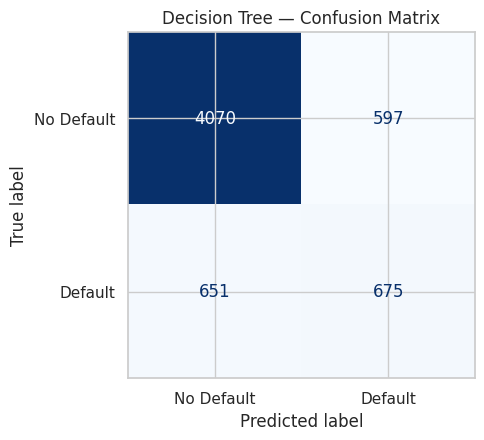

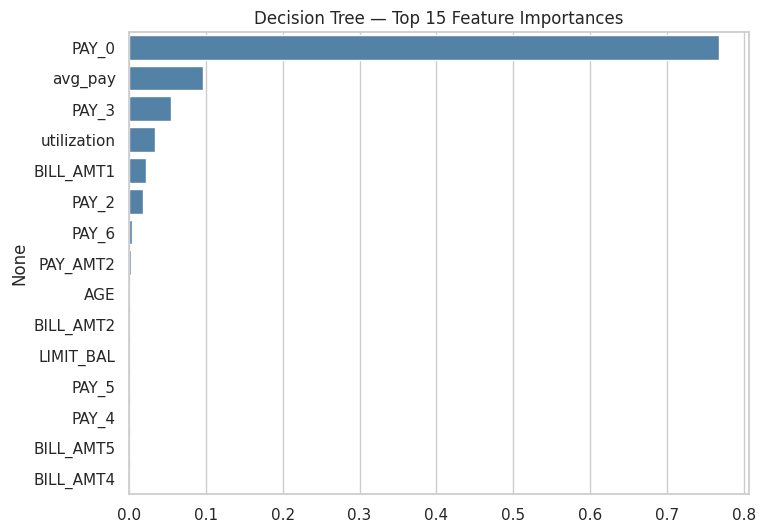


3. Random Forest — RandomizedSearchCV
Best Random Forest params: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 16}
Best CV F1: 0.5493

Random Forest — classification report:
              precision    recall  f1-score   support

  No Default     0.8704    0.8530    0.8616      4667
     Default     0.5166    0.5528    0.5341      1326

    accuracy                         0.7866      5993
   macro avg     0.6935    0.7029    0.6978      5993
weighted avg     0.7921    0.7866    0.7891      5993



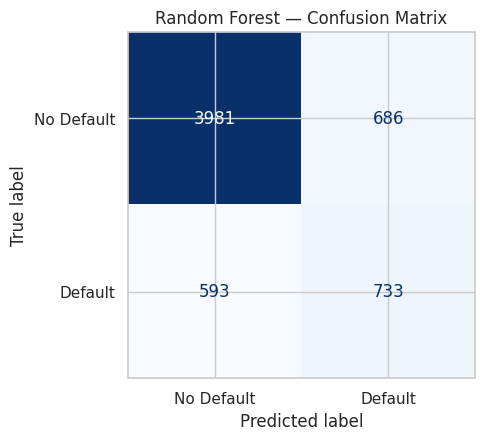

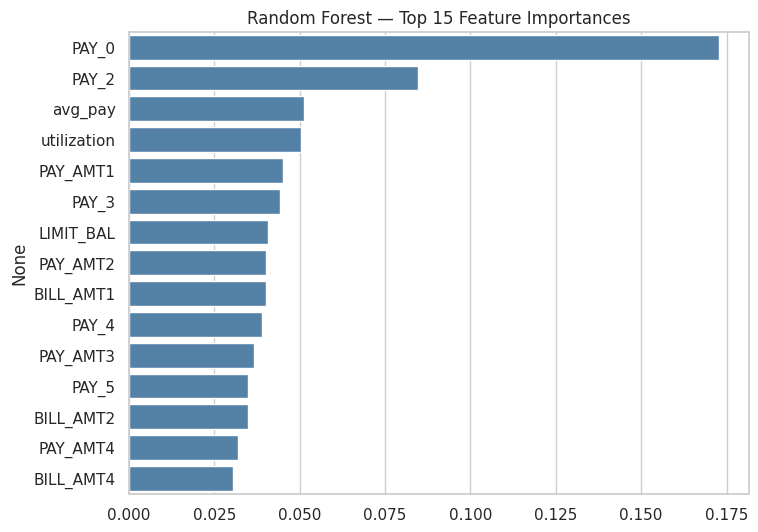


4. Comparison


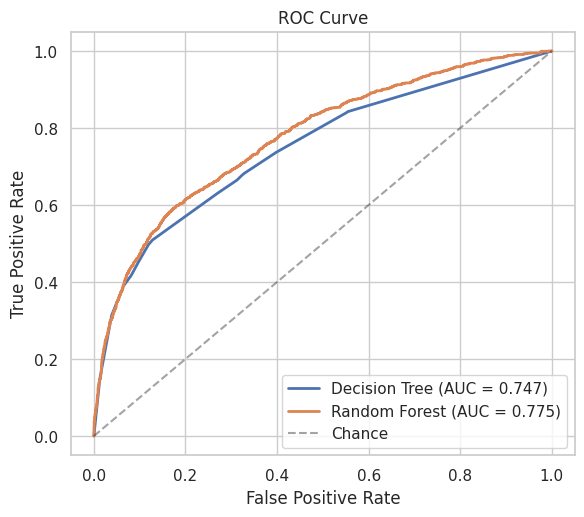

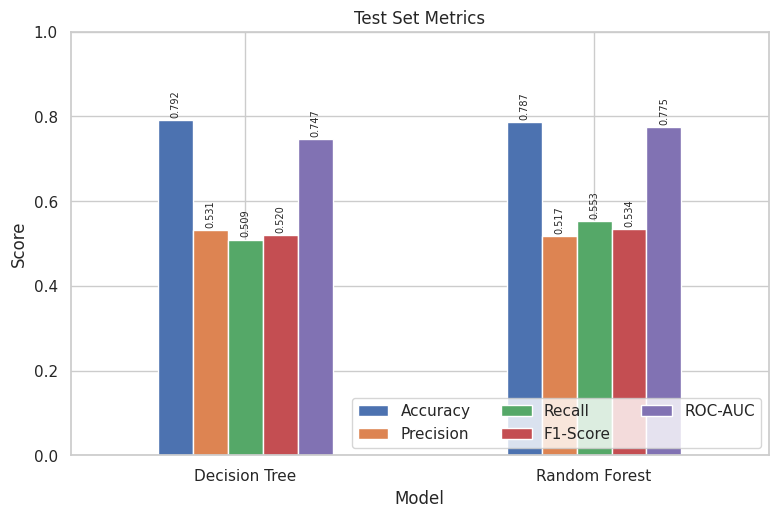

               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Decision Tree    0.7918     0.5307  0.5090    0.5196   0.7470
Random Forest    0.7866     0.5166  0.5528    0.5341   0.7749

5. Save models

Models and metrics saved to: /content/drive/MyDrive/ML_Ass_2/model_outputs


In [12]:
section("1. Load preprocessed data")
X_train, X_test, y_train, y_test = load_data()
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

results, proba_dict = [], {}

section("2. Decision Tree — GridSearchCV")
dt = tune_decision_tree(X_train, y_train)
proba_dict["Decision Tree"] = evaluate("Decision Tree", dt, X_test, y_test, results)
plot_feature_importance("Decision Tree", dt, X_train.columns)

section("3. Random Forest — RandomizedSearchCV")
rf = tune_random_forest(X_train, y_train)
proba_dict["Random Forest"] = evaluate("Random Forest", rf, X_test, y_test, results)
plot_feature_importance("Random Forest", rf, X_train.columns)

section("4. Comparison")
plot_roc(y_test, proba_dict)
results_df = pd.DataFrame(results).set_index("Model").round(4)
plot_metric_comparison(results_df)
print(results_df.to_string())
results_df.to_csv(OUT_DIR / "model_comparison.csv")

section("5. Save models")
joblib.dump(dt, OUT_DIR / "decision_tree_model.joblib")
joblib.dump(rf, OUT_DIR / "random_forest_model.joblib")
print(f"\nModels and metrics saved to: {OUT_DIR}")